# Step 1: The Perceptron

The perceptron (Rosenblatt, 1958) is the fundamental unit of all neural networks.
It computes a **weighted sum** of its inputs and passes the result through an **activation function**.

```
output = activation(w₁x₁ + w₂x₂ + ... + wₙxₙ + b)
       = activation(w · x + b)
```

**What you'll see in this notebook:**
1. A single neuron learning to classify AND — perfectly solvable
2. The same neuron failing on XOR — provably impossible
3. Why: a single neuron can only draw **one straight line** in input space
4. The sigmoid neuron: a soft, differentiable version that enables gradient descent

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

## The Perceptron Learning Rule

For a binary classification task:
- **Predict**: ŷ = step(w · x + b)  where step(z) = 1 if z > 0 else 0
- **Update**: w ← w + η · (y − ŷ) · x  and  b ← b + η · (y − ŷ)

### Why the update only fires on mistakes

The term `(y − ŷ)` can only take three values:

| True label y | Predicted ŷ | y − ŷ | What happens to w |
|:---:|:---:|:---:|:---|
| 0 | 0 | **0** | No update — prediction correct |
| 1 | 1 | **0** | No update — prediction correct |
| 1 | 0 | **+1** | `w ← w + η·x` — nudge weights *toward* this input |
| 0 | 1 | **−1** | `w ← w − η·x` — nudge weights *away* from this input |

When the prediction is correct, `(y − ŷ) = 0` makes the entire update term zero — nothing changes.
The weights only move when the model makes a mistake.

### What the update does geometrically

The weight vector `w` points perpendicular to the decision boundary.
Adding `η·x` to `w` rotates the boundary so that `x` is more likely to land on the correct side next time.
Subtracting `η·x` rotates it the other way.

### Worked numeric example (AND gate, first two steps)

Start: `w = [0, 0]`, `b = 0`, `η = 0.1`

**Step 1 — input [1,1], label y=1:**
```
ŷ = step([0,0]·[1,1] + 0) = step(0) = 0   ← wrong
y − ŷ = 1 − 0 = +1
w ← [0, 0] + 0.1 × (+1) × [1, 1] = [0.1, 0.1]
b ← 0    + 0.1 × (+1)             = 0.1
```

**Step 2 — input [0,0], label y=0:**
```
ŷ = step([0.1,0.1]·[0,0] + 0.1) = step(0.1) = 1   ← wrong
y − ŷ = 0 − 1 = −1
w ← [0.1, 0.1] + 0.1 × (−1) × [0, 0] = [0.1, 0.1]   ← x=[0,0] contributes nothing!
b ← 0.1         + 0.1 × (−1)           = 0.0
```

Notice that when the input is `[0,0]`, even a wrong prediction produces no weight change — because `(y − ŷ) · x = ±1 · [0,0] = [0,0]`. Only the bias shifts. This is a fundamental property of the update rule: **the magnitude of the correction is proportional to the input**.

**Convergence theorem**: if the data is linearly separable, the perceptron is guaranteed to find a solution in a finite number of steps.

In [1]:
class Perceptron:
    """Single neuron with step activation and the perceptron learning rule."""

    def __init__(self, n_features, lr=0.1):
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.lr = lr

    def predict(self, X):
        return (X @ self.w + self.b > 0).astype(int)

    def fit(self, X, y, epochs=20):
        """Train and return (errors_per_epoch, weight_history)."""
        errors_per_epoch = []
        weight_history = [self.w.copy()]
        for _ in range(epochs):
            errors = 0
            for xi, yi in zip(X, y):
                yhat = int(xi @ self.w + self.b > 0)
                delta = yi - yhat
                if delta != 0:
                    self.w += self.lr * delta * xi
                    self.b += self.lr * delta
                    errors += 1
            errors_per_epoch.append(errors)
            weight_history.append(self.w.copy())
        return errors_per_epoch, weight_history

## Task 1: AND Gate

AND is linearly separable — a single line can separate the one positive example from the three negative ones.

In [1]:
# Logic gate datasets
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_and = np.array([0, 0, 0, 1])
y_xor = np.array([0, 1, 1, 0])

# Train on AND
p_and = Perceptron(2, lr=0.1)
errors_and, weights_and = p_and.fit(X, y_and, epochs=20)

print("=== AND Gate ===")
print(f"Learned weights: {p_and.w},  bias: {p_and.b:.1f}")
print(f"Predictions: {p_and.predict(X)}  (correct: {y_and})")
print(f"Errors per epoch: {errors_and}")

=== AND Gate ===
Learned weights: [0.2 0.1],  bias: -0.2
Predictions: [0 0 0 1]  (correct: [0 0 0 1])
Errors per epoch: [1, 3, 3, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]



XOR final predictions: [1 1 0 0] (correct: [0 1 1 0] )


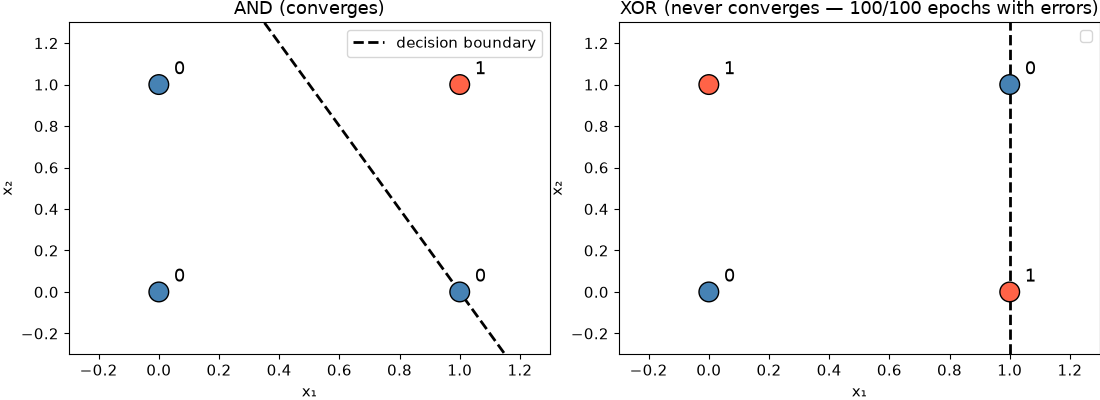

In [2]:
def plot_decision_boundary(ax, model, X, y, title):
    """Plot the linear decision boundary learned by the perceptron."""
    colors = ['steelblue' if yi == 0 else 'tomato' for yi in y]
    ax.scatter(X[:,0], X[:,1], c=colors, s=200, zorder=3, edgecolors='k')

    # Decision boundary: w[0]*x + w[1]*y + b = 0  =>  y = -(w[0]*x + b) / w[1]
    xs = np.linspace(-0.3, 1.3, 100)
    if abs(model.w[1]) > 1e-6:
        ys = -(model.w[0] * xs + model.b) / model.w[1]
        ax.plot(xs, ys, 'k--', lw=2, label='decision boundary')
    else:
        ax.axvline(x=-model.b / model.w[0], color='k', linestyle='--', lw=2)

    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.3, 1.3)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
    ax.set_title(title)
    ax.legend()
    for xi, yi in zip(X, y):
        ax.annotate(str(yi), xi + np.array([0.05, 0.05]), fontsize=13)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

plot_decision_boundary(axes[0], p_and, X, y_and, 'AND (converges)')

# XOR: train but it won't converge
p_xor = Perceptron(2, lr=0.1)
errors_xor, _ = p_xor.fit(X, y_xor, epochs=100)
plot_decision_boundary(axes[1], p_xor, X, y_xor,
    f'XOR (never converges — {sum(e>0 for e in errors_xor)}/100 epochs with errors)')

plt.tight_layout()
plt.savefig('01_decision_boundaries.png', bbox_inches='tight')
plt.show()
print("\nXOR final predictions:", p_xor.predict(X), "(correct:", y_xor, ")")

## Why XOR Is Impossible for a Single Neuron

A single neuron computes a **linear function** of its inputs. Its decision boundary is always
a hyperplane (a line in 2D). XOR requires two regions that cannot be separated by any single line:

```
  (0,1)=1    (1,1)=0
  
  (0,0)=0    (1,0)=1
```

The positive examples (0,1) and (1,0) are **diagonal** — no line separates them from the negatives.

This limitation was famously demonstrated by Minsky & Papert (1969) and temporarily halted perceptron research.
The fix: **stack multiple neurons** (a multi-layer network). We'll see this in the next notebook.

## The Sigmoid Neuron: Making Gradients Possible

The step function has gradient zero everywhere (except at 0 where it's undefined).
This makes gradient-based training impossible. The **sigmoid** function is a smooth, differentiable approximation:

```
σ(z) = 1 / (1 + e^{-z})
σ'(z) = σ(z) · (1 - σ(z))     # max value 0.25 at z=0
```

With sigmoid we can train using **gradient descent** instead of the perceptron rule.
This is the key that unlocks multi-layer networks.

Critical insight: sigmoid gradient max is 0.25.
Through 10 layers: max gradient = 0.25^10 = 9.5367431640625e-07


<string>:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


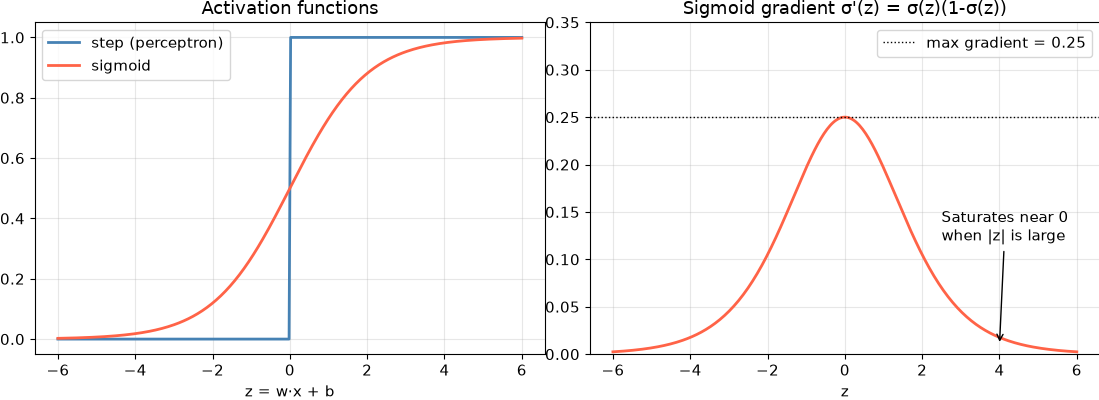

In [1]:
def sigmoid(z): return 1 / (1 + np.exp(-z))
def sigmoid_grad(z): s = sigmoid(z); return s * (1 - s)

z = np.linspace(-6, 6, 300)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: compare step vs sigmoid
axes[0].plot(z, (z > 0).astype(float), 'steelblue', lw=2, label='step (perceptron)')
axes[0].plot(z, sigmoid(z), 'tomato', lw=2, label='sigmoid')
axes[0].set_xlabel('z = w·x + b')
axes[0].set_title('Activation functions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: sigmoid gradient — the 0.25 maximum matters
axes[1].plot(z, sigmoid_grad(z), 'tomato', lw=2)
axes[1].axhline(0.25, color='k', linestyle=':', lw=1, label='max gradient = 0.25')
axes[1].set_xlabel('z')
axes[1].set_title("Sigmoid gradient σ'(z) = σ(z)(1-σ(z))")
axes[1].set_ylim(0, 0.35)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].annotate('Saturates near 0\nwhen |z| is large',
    xy=(4, 0.01), xytext=(2.5, 0.12),
    arrowprops=dict(arrowstyle='->', color='k'))

plt.tight_layout()
plt.savefig('01_sigmoid.png', bbox_inches='tight')
plt.show()
print("Critical insight: sigmoid gradient max is 0.25.")
print("Through 10 layers: max gradient = 0.25^10 =", 0.25**10)

## Train a Sigmoid Neuron with Gradient Descent

Binary cross-entropy loss: L = -[y log(ŷ) + (1-y) log(1-ŷ)]

The gradient with respect to weights: ∂L/∂w = (ŷ - y) · x

This is the same form as the perceptron rule but derived from calculus, and now ŷ is a probability.

Predicted probabilities: ['0.000', '0.049', '0.049', '0.932']
True labels:             [0 0 0 1]


<string>:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


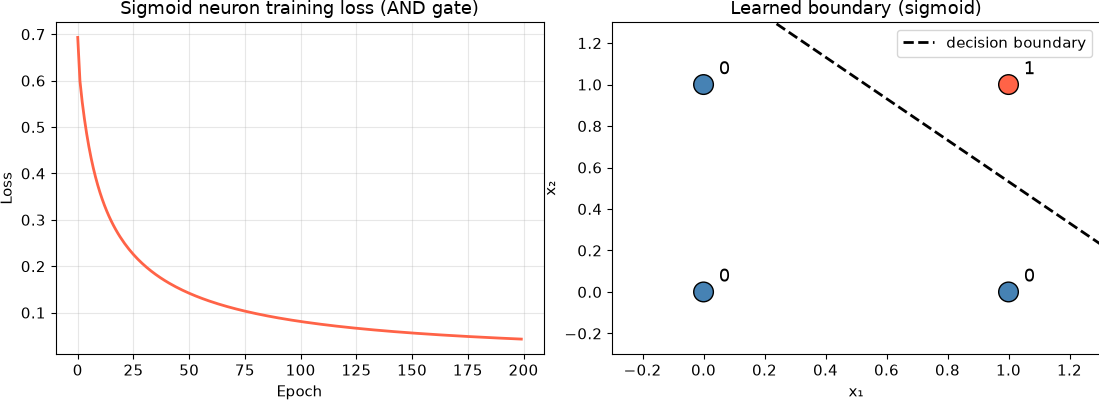

In [1]:
class SigmoidNeuron:
    """Single neuron with sigmoid activation trained by gradient descent."""

    def __init__(self, n_features, lr=1.0):
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.lr = lr

    def predict_proba(self, X):
        return sigmoid(X @ self.w + self.b)

    def fit(self, X, y, epochs=200):
        losses = []
        for _ in range(epochs):
            yhat = self.predict_proba(X)
            # Binary cross-entropy loss
            loss = -np.mean(y * np.log(yhat + 1e-9) + (1-y) * np.log(1-yhat + 1e-9))
            losses.append(loss)
            # Gradient: dL/dw = (yhat - y) * x, averaged over batch
            grad_w = (yhat - y) @ X / len(y)
            grad_b = np.mean(yhat - y)
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b
        return losses

sn = SigmoidNeuron(2, lr=2.0)
losses = sn.fit(X, y_and)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(losses, 'tomato', lw=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Sigmoid neuron training loss (AND gate)')
ax1.grid(True, alpha=0.3)

plot_decision_boundary(ax2, sn, X, y_and, 'Learned boundary (sigmoid)')

plt.tight_layout()
plt.savefig('01_sigmoid_training.png', bbox_inches='tight')
plt.show()

probs = sn.predict_proba(X)
print("Predicted probabilities:", [f"{p:.3f}" for p in probs])
print("True labels:            ", y_and)

## Key Takeaways

| Concept | What we learned |
|---|---|
| **Single neuron** | Computes a linear function; draws one hyperplane |
| **Perceptron rule** | Converges if data is linearly separable; fails otherwise |
| **XOR is impossible** | Not a limitation of learning — a fundamental geometric constraint |
| **Sigmoid activation** | Smooth, differentiable; enables gradient descent |
| **Sigmoid gradient** | Max 0.25; saturation at large |z| — problem for deep networks |
| **Cross-entropy loss** | Natural loss for binary classification; gradient has clean form |

**What's still missing**: a single neuron can only represent linear functions. 
To solve XOR (and real problems), we need **multiple layers**. Next: MLP + Backpropagation.